In [18]:
from os import wait

import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np
from utils import (download_json)
import time

In [19]:
coords = pd.read_csv("coordinates_transect_points.csv")
coords.head()

,id,lat,lon,id_transec
0,NaN,46.991595,7.024213,1
1,NaN,46.989612,7.020898,1
2,NaN,46.987318,7.016730,1
3,NaN,46.984838,7.012519,1
4,NaN,46.982606,7.008622,1


In [20]:
dfs = []

for i, coord in coords.iterrows():
    url = fr"https://alplakes-api.eawag.ch/remotesensing/timeseries/neuchatel/collection/ST/{coord['lat']}/{coord['lon']}/20240101/20250101?window=2&valid_pixels=50"
    data = download_json(url)

    time_arr = []
    val_arr = []
    for pack in data:
        time_arr.append(pack["time"])
        val_arr.append(pack["value"]["mean"])

    time_dt = pd.to_datetime(time_arr, utc=True).tz_convert(None)

    df = pd.DataFrame(
        {
            "time": time_dt,
            "value": val_arr,
            "point": i,
            "transect_number": coord["id_transec"],
            "lat": coord["lat"],
            "lon": coord["lon"],
        }
    )

    dfs.append(df)

    time.sleep(2)


In [21]:
df_data = pd.concat(dfs)

In [22]:
df_data

,time,value,point,transect_number,lat,lon
0,2024-12-04 12:00:00,6.626590,0,1.0,46.991595,7.024213
1,2024-12-04 12:00:00,6.661044,0,1.0,46.991595,7.024213
2,2024-09-15 12:00:00,16.606525,0,1.0,46.991595,7.024213
3,2024-09-15 12:00:00,16.616507,0,1.0,46.991595,7.024213
4,2024-09-14 12:00:00,15.386049,0,1.0,46.991595,7.024213
...,...,...,...,...,...,...
21,2024-03-23 12:00:00,8.111925,27,3.0,46.979224,6.978098
22,2024-03-23 12:00:00,8.147882,27,3.0,46.979224,6.978098
23,2024-02-20 12:00:00,6.546471,27,3.0,46.979224,6.978098
24,2024-02-04 12:00:00,1.770404,27,3.0,46.979224,6.978098


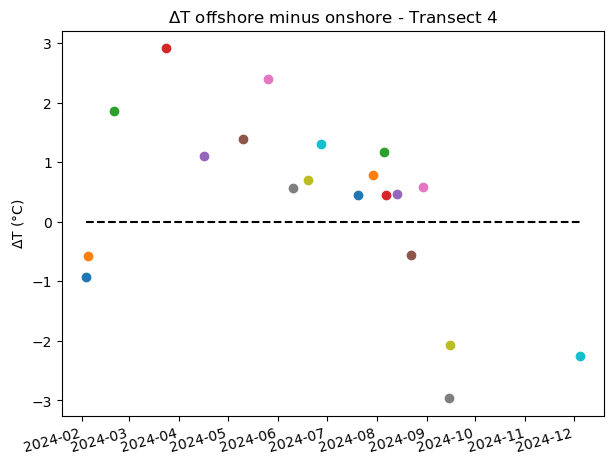

In [23]:
transect_number = 4
df_transect = df_data[df_data['transect_number']==transect_number]
times = np.sort(pd.unique(df_transect['time']))
plt.figure(figsize=(7, 5))
plt.title(rf"$\Delta$T offshore minus onshore - Transect {transect_number}")
plt.ylabel(r"$\Delta$T (°C)")
plt.xticks(rotation=15, ha='right')
plt.hlines(0, times[0], times[-1], colors='black', linestyles='dashed')
for t in times:
    df_snap = df_transect[df_transect['time']==t]
    plt.scatter(df_snap.iloc[-1]['time'], df_snap.iloc[0]['value'] - df_snap.iloc[-1]['value'])

# MITgcm results

In [24]:
import sys
import os
import numpy as np
import datetime

import matplotlib.pyplot as plt

sys.path.append('..//mitgcm')
from utils_mitgcm import open_mitgcm_ds_from_config
#%matplotlib notebook

In [25]:
lake = 'neuchatel'
model = f'neuchatel_200m_2024'
mitgcm_config, ds_to_plot = open_mitgcm_ds_from_config('..//mitgcm//config.json', model)

In [26]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "figures")
os.makedirs(output_folder, exist_ok=True)

In [27]:
plot_line = 15000

In [28]:
grid_resolution = 200
ds_to_plot['YC'] = np.arange(1, len(ds_to_plot['YC'])+1) * grid_resolution - grid_resolution/2
ds_to_plot['XC'] = np.arange(1, len(ds_to_plot['XC'])+1) * grid_resolution - grid_resolution/2
ds_to_plot['YG'] = np.arange(0, len(ds_to_plot['YG'])) * grid_resolution
ds_to_plot['XG'] = np.arange(0, len(ds_to_plot['XG'])) * grid_resolution

In [29]:
ds_to_plot['THETA'] = ds_to_plot['THETA'].where(ds_to_plot['THETA'] != 0, np.nan)

In [30]:
aligned_u = ds_to_plot.UVEL.rename({'XG':'XC'})
aligned_u['XC'] = ds_to_plot['XC']

aligned_v = ds_to_plot.VVEL.rename({'YG':'YC'})
aligned_v['YC'] = ds_to_plot['YC']

aligned_w = ds_to_plot.WVEL.rename({'Zl':'Z'})
aligned_w['Z'] = ds_to_plot['Z']

In [31]:
coords_mitgcm = pd.read_csv("coordinates_transect_points_with_mitgcm_coords.csv")

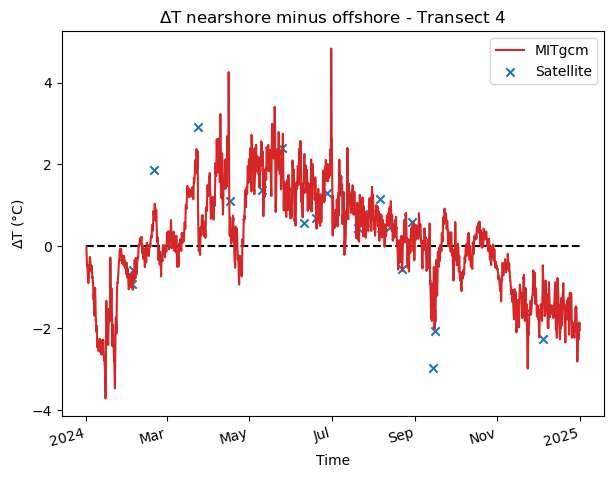

In [35]:
transect_number = 4
df_transect = coords_mitgcm[coords_mitgcm['id_transec']==transect_number]
nearshore_timeserie = ds_to_plot.THETA.isel(Z=0).sel(XC=df_transect['x_mitgcm'].iloc[0], YC=df_transect['y_mitgcm'].iloc[0], method='nearest')
offshore_timeserie = ds_to_plot.THETA.isel(Z=0).sel(XC=df_transect['x_mitgcm'].iloc[-1], YC=df_transect['y_mitgcm'].iloc[-1], method='nearest')
delta_T = nearshore_timeserie - offshore_timeserie
plt.figure(figsize=(7, 5))
plt.xticks(rotation=15, ha='right')
plt.hlines(0, delta_T.time.values[0], delta_T.time.values[-1], colors='black', linestyles='dashed')

#MITgcm
delta_T.plot(label="MITgcm", color='tab:red')

# Satellite
df_data_transect = df_data[df_data['transect_number']==transect_number]
times = np.sort(pd.unique(df_data_transect['time']))
sat_deltat_val = []
for t in times:
    df_snap = df_data_transect[df_data_transect['time']==t]
    sat_deltat_val.append(df_snap.iloc[0]['value'] - df_snap.iloc[-1]['value'])

plt.scatter(times, sat_deltat_val, label="Satellite", color='tab:blue', marker='x')

plt.title(rf"$\Delta$T nearshore minus offshore - Transect {transect_number}")
plt.ylabel(r"$\Delta$T (°C)")
plt.legend()